In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec


import os

import seaborn as sns



# Load data

In [2]:
# Load barcode dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris
atac_bc,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO


In [3]:
# Load fragments file
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_BC'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])
frag['frag_length'] = frag['end'] - frag['start']



In [6]:
frag_in_Raw_peak_file = os.path.join(Union_cell_subdir, 'Rawpeaks', 'frag_overlap/frag_in_peaks.tsv')

frag_in_Entropy_peak_file = os.path.join(Union_cell_subdir, 'Entropy_cells_peaks', 'frag_overlap/frag_in_peaks.tsv')
frag_in_TSS_peak_file = os.path.join(Union_cell_subdir, 'TSS_cells_peaks', 'frag_overlap/frag_in_peaks.tsv')
frag_in_FRIP_peak_file = os.path.join(Union_cell_subdir, 'FRIP_cells_peaks', 'frag_overlap/frag_in_peaks.tsv')


frag_in_raw_peaks = pd.read_csv(frag_in_Raw_peak_file, sep='\t', index_col=3, header=None)
frag_in_entropy_peaks = pd.read_csv(frag_in_Entropy_peak_file, sep='\t', index_col=3, header=None)
frag_in_tss_peaks = pd.read_csv(frag_in_TSS_peak_file, sep='\t', index_col=3, header=None)
frag_in_frip_peaks = pd.read_csv(frag_in_FRIP_peak_file, sep='\t', index_col=3, header=None)

for df in [frag_in_raw_peaks, frag_in_entropy_peaks, frag_in_tss_peaks, frag_in_frip_peaks]:
    df.index.name ='atac_BC'
    df.columns = ['chrom', 'start', 'end', 'support']
    df['atac_bc'] = df.index.map(lambda x: x.split('-1')[0])
    df['frag_length'] = df['end'] - df['start']

In [9]:
frag_in_frip_peaks.groupby('atac_bc').size()

atac_bc
AAACAAGCAAGTTAGT    1780
AAACAAGCATTTCTTC    1606
AAACCGCCAACGGTAC    1306
AAACCGCCAGAAACCC     409
AAACGAACACCTGTAT    1217
                    ... 
TTTGGAGCATAAGTCG    9686
TTTGTCGAGCTAGTTT    2721
TTTGTGAGTCATCACG    4109
TTTGTGAGTGCTCATG    7607
TTTGTGAGTTGAGTCT    3265
Length: 2384, dtype: int64

# FRIP on each peak-set comparision among 3 cell-calling approaches

## FRIP distribution

In [10]:
total_frag_per_bc = union_cell_info.copy()
total_frag_per_bc['Nfrag_in_raw_peaks'] = total_frag_per_bc.index.map(frag_in_raw_peaks.groupby('atac_bc').size())
total_frag_per_bc['Nfrag_in_entropy_peaks'] = total_frag_per_bc.index.map(frag_in_entropy_peaks.groupby('atac_bc').size())
total_frag_per_bc['Nfrag_in_tss_peaks'] = total_frag_per_bc.index.map(frag_in_tss_peaks.groupby('atac_bc').size())
total_frag_per_bc['Nfrag_in_frip_peaks'] = total_frag_per_bc.index.map(frag_in_frip_peaks.groupby('atac_bc').size())

total_frag_per_bc['FRIP_raw_peaks'] = total_frag_per_bc['Nfrag_in_raw_peaks'] / total_frag_per_bc['total_fragments'] * 100 
total_frag_per_bc['FRIP_entropy_peaks'] = total_frag_per_bc['Nfrag_in_entropy_peaks'] / total_frag_per_bc['total_fragments'] * 100
total_frag_per_bc['FRIP_tss_peaks'] = total_frag_per_bc['Nfrag_in_tss_peaks'] / total_frag_per_bc['total_fragments'] * 100
total_frag_per_bc['FRIP_frip_peaks'] = total_frag_per_bc['Nfrag_in_frip_peaks'] / total_frag_per_bc['total_fragments'] * 100

----- 	 CR_2ndRound 	 ArchR 	 entropy_only
mean 	 [np.float64(66.00780615077853), np.float64(11.592510005134741), np.float64(41.89112131290475), np.float64(34.28448641345996)]
median 	 [np.float64(67.24391490616043), np.float64(4.096050751707233), np.float64(57.407407407407405), np.float64(40.58988764044944)]


Text(0.5, 0.98, 'Distribution of FRIP (in Raw peaks)')

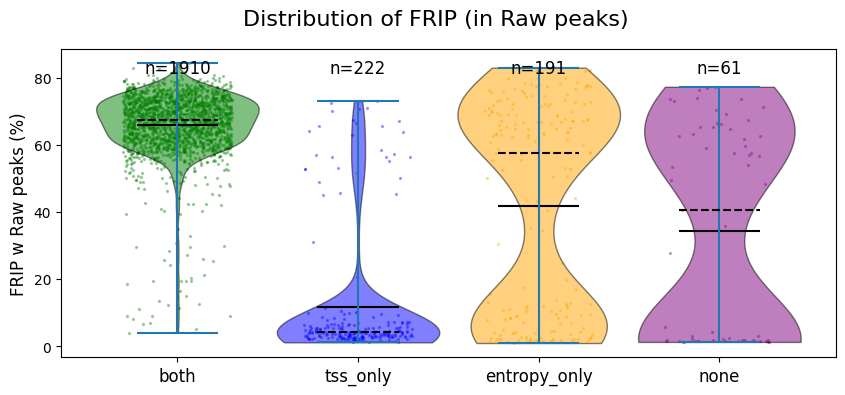

In [21]:
fig, ax = plt.subplots(ncols=1, figsize=(10, 4))

x_positions = range(4)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ total_frag_per_bc['FRIP_raw_peaks'].loc[total_frag_per_bc['_2set_identified_by_atac_ST'] == cat ] for cat in ['both', 'tss_only', 'entropy_only', 'none'] ]
total_counts = [ frip.shape[0] for frip in frip_values ]

mean_frip_values = [np.mean(a) for a in frip_values]
median_frip_values = [np.median(a) for a in frip_values]
# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['both', 'tss_only', 'entropy_only', 'none'], 
                   rotation=0, ha='center', fontsize=12)
ax.set_ylabel('FRIP w Raw peaks (%)', fontsize=12)
# ax.set_ylim(19, 25)
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

print('----- \t CR_2ndRound \t ArchR \t entropy_only')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

fig.suptitle('Distribution of FRIP (in Raw peaks)', fontsize=16)

----- 	 CR_2ndRound 	 ArchR 	 entropy_only
mean 	 [np.float64(65.57818445750814), np.float64(41.28354330102483), np.float64(49.884745362284406), np.float64(4.149406465950456)]
median 	 [np.float64(67.1978235522736), np.float64(53.705714088778606), np.float64(63.25401696488992), np.float64(3.6585365853658534)]


Text(0.5, 0.98, 'Distribution of FRIP (in Raw peaks)')

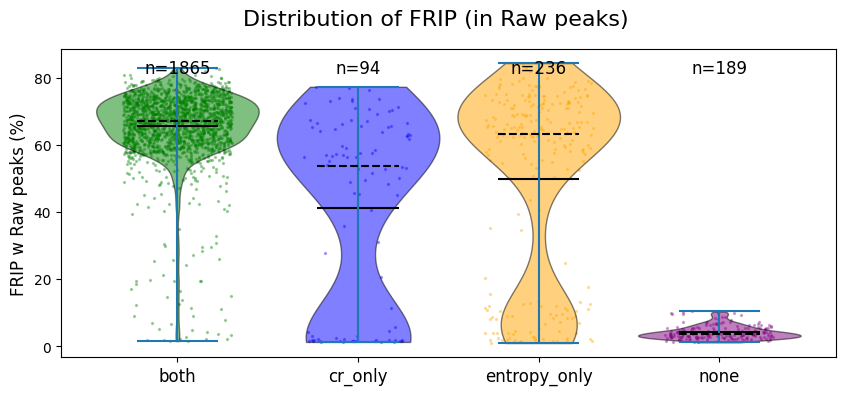

In [22]:
fig, ax = plt.subplots(ncols=1, figsize=(10, 4))

x_positions = range(4)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ total_frag_per_bc['FRIP_raw_peaks'].loc[total_frag_per_bc['_2set_identified_by_atac_SC'] == cat ] for cat in ['both', 'cr_only', 'entropy_only', 'none'] ]
total_counts = [ frip.shape[0] for frip in frip_values ]

mean_frip_values = [np.mean(a) for a in frip_values]
median_frip_values = [np.median(a) for a in frip_values]
# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['both', 'cr_only', 'entropy_only', 'none'], 
                   rotation=0, ha='center', fontsize=12)
ax.set_ylabel('FRIP w Raw peaks (%)', fontsize=12)
# ax.set_ylim(19, 25)
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

print('----- \t CR_2ndRound \t ArchR \t entropy_only')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

fig.suptitle('Distribution of FRIP (in Raw peaks)', fontsize=16)

## On the whole peak-set

/tmp/ipykernel_3700708/957562121.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'],
/tmp/ipykernel_3700708/957562121.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'],
/tmp/ipykernel_3700708/957562121.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[2].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'],


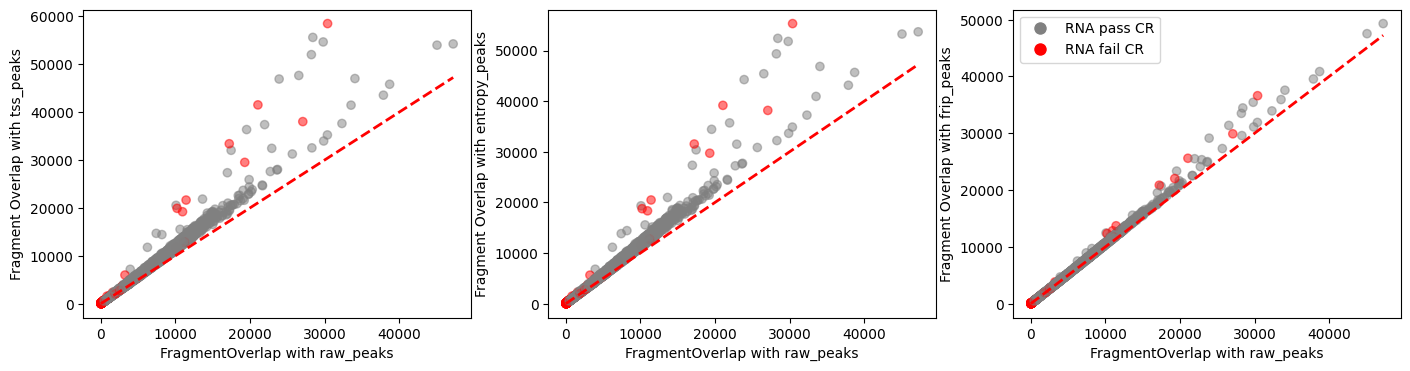

In [17]:
fig, ax = plt.subplots(ncols=3, figsize=(17, 4))

ylabel = 'tss_peaks'
xlabel = 'raw_peaks'
ax[0].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'], 
           total_frag_per_bc[f'Nfrag_in_{ylabel}'], 
           c =total_frag_per_bc['rna_pass_CR'].map({True: 'grey', False: 'red'}), cmap='Set1', alpha=0.5)
ax[0].set_xlabel(f'FragmentOverlap with {xlabel}')
ax[0].set_ylabel(f'Fragment Overlap with {ylabel}')
vmax = total_frag_per_bc[f'Nfrag_in_{xlabel}'].max()
ax[0].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)


ylabel = 'entropy_peaks'
xlabel = 'raw_peaks'
ax[1].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'], 
           total_frag_per_bc[f'Nfrag_in_{ylabel}'], 
           c =total_frag_per_bc['rna_pass_CR'].map({True: 'grey', False: 'red'}), cmap='Set1', alpha=0.5)
ax[1].set_xlabel(f'FragmentOverlap with {xlabel}')
ax[1].set_ylabel(f'Fragment Overlap with {ylabel}')
vmax = total_frag_per_bc[f'Nfrag_in_{xlabel}'].max()
ax[1].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)


ylabel = 'frip_peaks'
xlabel = 'raw_peaks'
ax[2].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'], 
           total_frag_per_bc[f'Nfrag_in_{ylabel}'], 
           c =total_frag_per_bc['rna_pass_CR'].map({True: 'grey', False: 'red'}), cmap='Set1', alpha=0.5)
ax[2].set_xlabel(f'FragmentOverlap with {xlabel}')
ax[2].set_ylabel(f'Fragment Overlap with {ylabel}')
vmax = total_frag_per_bc[f'Nfrag_in_{xlabel}'].max()
ax[2].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)

ax[2].legend(handles=[Line2D([0], [0], marker='o', color='w', label='RNA pass CR', markerfacecolor='grey', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='RNA fail CR', markerfacecolor='red', markersize=10)], loc='upper left')

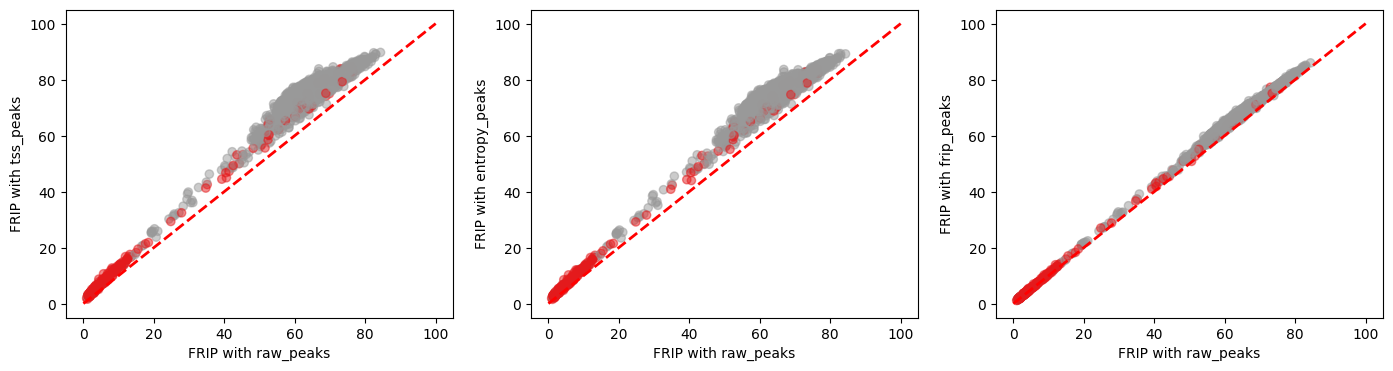

In [20]:
fig, ax = plt.subplots(ncols=3, figsize=(17, 4))

ylabel = 'tss_peaks'
xlabel = 'raw_peaks'
ax[0].scatter(total_frag_per_bc[f'FRIP_{xlabel}'], 
           total_frag_per_bc[f'FRIP_{ylabel}'],
           c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[0].set_xlabel(f'FRIP with {xlabel}')
ax[0].set_ylabel(f'FRIP with {ylabel}')


ylabel = 'entropy_peaks'
xlabel = 'raw_peaks'
ax[1].scatter(total_frag_per_bc[f'FRIP_{xlabel}'], 
           total_frag_per_bc[f'FRIP_{ylabel}'], 
           c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[1].set_xlabel(f'FRIP with {xlabel}')
ax[1].set_ylabel(f'FRIP with {ylabel}')

ylabel = 'frip_peaks'
xlabel = 'raw_peaks'
ax[2].scatter(total_frag_per_bc[f'FRIP_{xlabel}'], 
           total_frag_per_bc[f'FRIP_{ylabel}'], 
           c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[2].set_xlabel(f'FRIP with {xlabel}')
ax[2].set_ylabel(f'FRIP with {ylabel}')

for a in ax:
    a.plot([0, 100], [0, 100],  color='red', linestyle='--', linewidth=2)

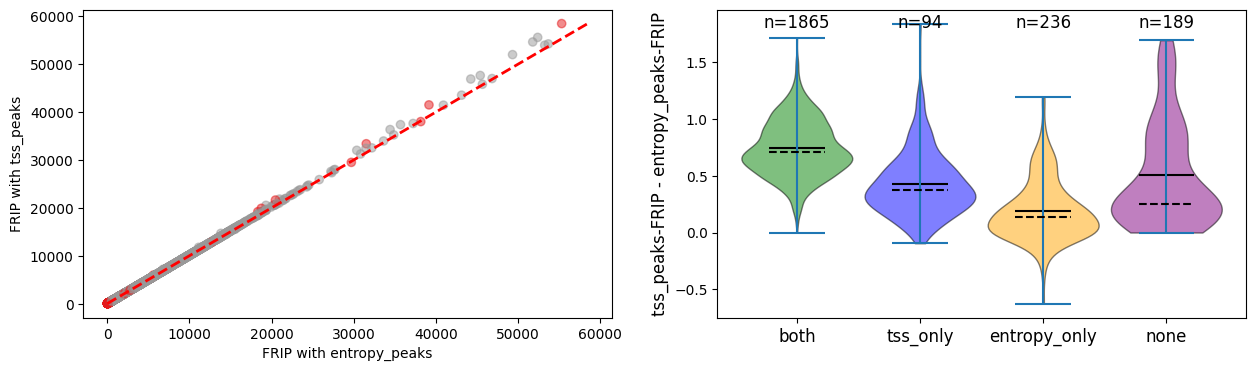

In [41]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 4))  
xlabel = 'entropy_peaks'
ylabel = 'tss_peaks'
ax[0].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'], 
              total_frag_per_bc[f'Nfrag_in_{ylabel}'], 
              c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[0].set_xlabel(f'FRIP with {xlabel}')
ax[0].set_ylabel(f'FRIP with {ylabel}')

vmax = max(total_frag_per_bc[f'Nfrag_in_{xlabel}'].max(), total_frag_per_bc[f'Nfrag_in_{ylabel}'].max())
ax[0].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)



x_positions = range(4)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ total_frag_per_bc[f'FRIP_{ylabel}'].loc[total_frag_per_bc['_2set_identified_by_atac_ST'] == cat ] - \
                total_frag_per_bc[f'FRIP_{xlabel}'].loc[total_frag_per_bc['_2set_identified_by_atac_ST'] == cat ] 
               for cat in ['both', 'tss_only', 'entropy_only', 'none'] ]



v1 = ax[1].violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax[1].set_xticks(x_positions)
ax[1].set_xticklabels(['both', 'tss_only', 'entropy_only', 'none'], 
                   rotation=0, ha='center', fontsize=12)
ax[1].set_ylabel(f'{ylabel}-FRIP - {xlabel}-FRIP', fontsize=12)


for i, count in enumerate(total_counts):
    ax[1].text(x_positions[i], ax[1].get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

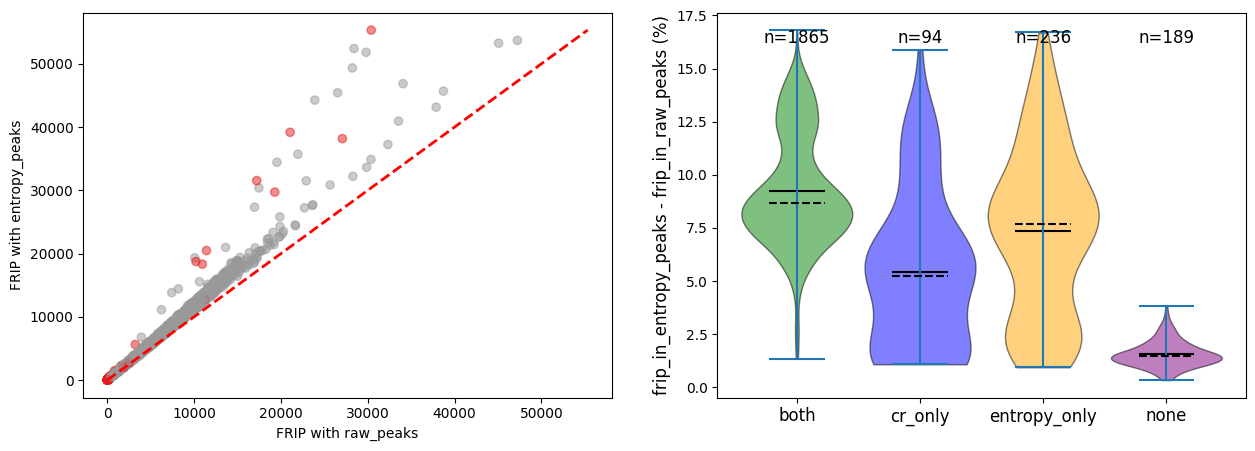

In [48]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))  
ylabel = 'entropy_peaks'
xlabel = 'raw_peaks'
ax[0].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'], 
              total_frag_per_bc[f'Nfrag_in_{ylabel}'], 
              c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[0].set_xlabel(f'FRIP with {xlabel}')
ax[0].set_ylabel(f'FRIP with {ylabel}')

vmax = max(total_frag_per_bc[f'Nfrag_in_{xlabel}'].max(), total_frag_per_bc[f'Nfrag_in_{ylabel}'].max())
ax[0].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)



x_positions = range(4)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ total_frag_per_bc[f'FRIP_{ylabel}'].loc[total_frag_per_bc['_2set_identified_by_atac_SC'] == cat ] - \
                total_frag_per_bc[f'FRIP_{xlabel}'].loc[total_frag_per_bc['_2set_identified_by_atac_SC'] == cat ] 
               for cat in ['both', 'cr_only', 'entropy_only', 'none'] ]



v1 = ax[1].violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax[1].set_xticks(x_positions)
ax[1].set_xticklabels(['both', 'cr_only', 'entropy_only', 'none'], 
                   rotation=0, ha='center', fontsize=12)
ax[1].set_ylabel(f'frip_in_{ylabel} - frip_in_{xlabel} (%)', fontsize=12)


for i, count in enumerate(total_counts):
    ax[1].text(x_positions[i], ax[1].get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

## 